<a href="https://colab.research.google.com/github/ivashenceva220495-beep/My_first_repository/blob/main/%D0%94%D0%972_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('data_hw_reg.xlsx')
df.head()

,date,country,confirmed,deaths
0,2020-01-22,Russia,0,0
1,2020-01-22,US,1,0
2,2020-01-23,Russia,0,0
3,2020-01-23,US,1,0
4,2020-01-24,Russia,0,0


In [ ]:
df_1 = df[df['country'] == 'Russia']
df_1.describe()

,confirmed,deaths
count,5.580000e+02,558.000000
mean,2.300445e+06,48404.983871
std,2.010516e+06,47780.244038
min,0.000000e+00,0.000000
25%,4.867282e+05,6188.000000
50%,1.528971e+06,26250.500000
75%,4.348391e+06,90858.000000
max,6.207513e+06,156726.000000


In [ ]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 558 entries, 0 to 1114
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       558 non-null    datetime64[ns]
 1   country    558 non-null    object        
 2   confirmed  558 non-null    int64         
 3   deaths     558 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 21.8+ KB


In [ ]:
#Корреляция заболеваемости к смертности
df['confirmed'].corr(df['deaths'])

0.9898359549904744

In [ ]:
#формирование выборки по смертям от заболеваемости
x = df_1[['deaths']]
y = df_1[['confirmed']]

In [ ]:
from sklearn.linear_model import LinearRegression # подключение модуля линейной регрессии
regressor = LinearRegression()                    # инициализация линейной регрессии
regressor.fit (x,y)                               # обучение линейной регрессии

LinearRegression()

In [ ]:
# Коэффициент прямой
a = regressor.intercept_
a

array([284192.47348256])

In [ ]:
# Коэффициент наклона прямой
b = regressor.coef_
b

array([[41.65381685]])

In [ ]:
confirmed_pred = 25000000 #Значение заболеваемости для получения прогноза смертей
regressor.predict ([[confirmed_pred]]) # Получение прогноза линейной регрессии

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[1.04162961e+09]])

In [ ]:
# Получение прогноза "в лоб" по уравнению прямой регрессии а + bx
a + b * confirmed_pred

array([[1.04162961e+09]])

In [ ]:
#Матрица корреляции средствами пандас
df.corr().style.background_gradient(cmap='coolwarm')

<ipython-input-16-af4c3c27893c>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr().style.background_gradient(cmap='coolwarm')


,confirmed,deaths
confirmed,1.000000,0.989836
deaths,0.989836,1.000000


<ipython-input-17-543a25016d82>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap (df.corr(), annot = True, vmin = -1, vmax =1,center = 0,cmap = 'coolwarm')


<Axes: >

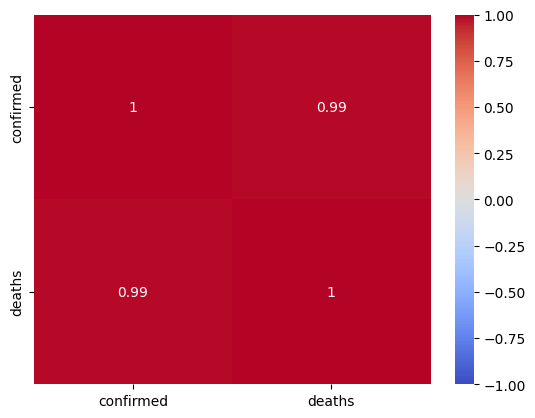

In [ ]:
#Матрица корреляции средствами визуализации seaborn (тепловая матрица)
sns.heatmap (df.corr(), annot = True, vmin = -1, vmax =1,center = 0,cmap = 'coolwarm')

Визуализация динамик заболеваемости и смертности по странам

In [ ]:
df_1 = df[df['country'] == 'Russia']
df_2 = df[df['country'] == 'US']

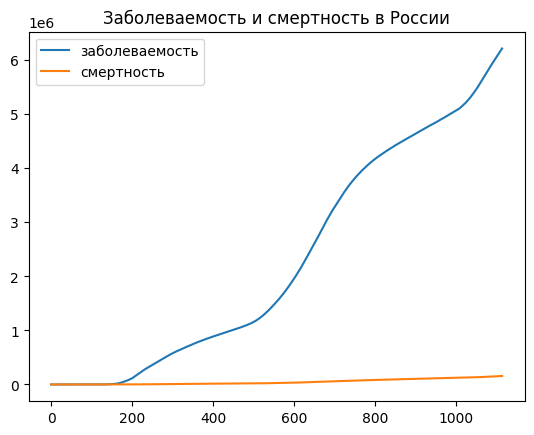

In [ ]:
plt.plot(df_1['confirmed'])
plt.plot(df_1['deaths'])
plt.title('Заболеваемость и смертность в России')
plt.legend(['заболеваемость', 'смертность'])
plt.show()

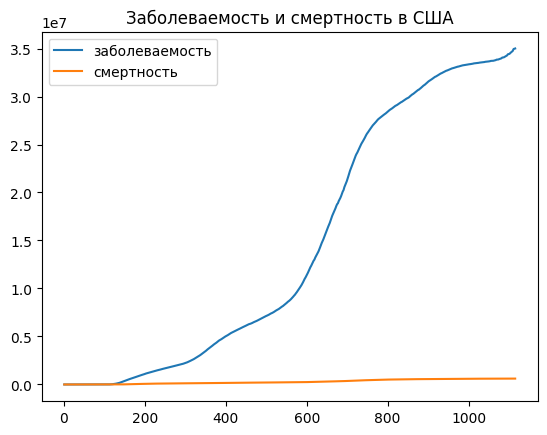

In [ ]:
plt.plot(df_2['confirmed'])
plt.plot(df_2['deaths'])
plt.title('Заболеваемость и смертность в США')
plt.legend(['заболеваемость', 'смертность'])
plt.show()

Заболеваемость и смертность явно коррелирует
Заболеваемость и смертность растёт
Темп распространения берётся под контроль